#  Task 2: Credit Risk Prediction

**Internship:** DevelopersHub Corporation — Data Science & Analytics

---

##  Problem Statement

Banks ko yeh decide karna hota hai ke kaunse customers ko loan dena safe hai aur kaunse nahi.
Is task mein hum **Machine Learning** use karenge taake automatically predict ho sake:

> **Kya yeh applicant loan wapas karega (Approved) ya default karega (Rejected)?**

---

##  Dataset Description — Loan Prediction Dataset

| Column | Matlab | Type |
|--------|--------|------|
| `Loan_ID` | Har loan ka unique ID | Text |
| `Gender` | Applicant ka gender | Text |
| `Married` | Shadi shuda hai ya nahi | Text |
| `Dependents` | Kitne log upar dependent hain | Number |
| `Education` | Graduate hai ya nahi | Text |
| `Self_Employed` | Khud ka kaam hai ya nahi | Text |
| `ApplicantIncome` | Applicant ki monthly income | Number |
| `CoapplicantIncome` | Co-applicant ki income | Number |
| `LoanAmount` | Kitna loan chahiye (hazaar mein) | Number |
| `Loan_Amount_Term` | Kitne mahine mein wapas karega | Number |
| `Credit_History` | Pehle ka credit record acha tha? (1=Haan, 0=Nahi) | Number |
| `Property_Area` | Ghar kahan hai (Urban/Rural/Semiurban) | Text |
| `Loan_Status` | **Loan mila ya nahi (Y/N)** ← Yahi predict karna hai | Text |

---
## Step 1: Libraries Import Karna

| Library | Kaam |
|---------|------|
| `pandas` | Data load aur clean karna |
| `matplotlib` | Graphs banana |
| `seaborn` |  statistical graphs |
| `sklearn` | Machine Learning model banana aur evaluate karna |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print(' Libraries import ho gayi!')

 Libraries import ho gayi!


---
## Step 2: Dataset Load Karna

**Task Requirement:** *Handle missing data appropriately*

Pehle data load karte hain aur uski basic structure dekhte hain.

In [ ]:
# CSV file load karo
bank_df = pd.read_csv('loan_data.csv')
print(' Dataset load ho gaya!')
#shape of the data
print(f'Dataset mein {bank_df.shape[0]} rows aur {bank_df.shape[1]} columns hain.')
bank_df.head()

 Dataset load ho gaya!
Dataset mein 381 rows aur 13 columns hain.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


---
## Step 3: Dataset Structure Dekhna

| Function | Kya Batata Hai |
|----------|----------------|
| `.columns` | Saare column names |
| `.info()` | Data types aur missing values |
| `.shape` | Kitni rows aur columns |
| `.duplicated()` | Duplicate rows toh nahi? |

In [5]:
print(' Column Names:')
print(bank_df.columns.tolist())

 Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [ ]:
print(' Dataset Info (.info()):')
print(bank_df.info())
print(' Duplicate rows:', bank_df.duplicated().sum())

 Dataset Info (.info()):
<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          381 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 38.8 KB
None

 Shape: (381, 13)
 Duplicate rows: 0


---
## Step 4: Approved Loans ki Basic Statistics

Yahan hum sirf **approved** loans ko filter karke dekhenge:
- Minimum aur maximum income kya thi jo loan mila?
- Minimum aur maximum loan amount kya tha?

In [7]:
# Sirf approved loans filter karo
approved = bank_df[bank_df['Loan_Status'] == 'Y']

print(' Approved Loans ki Statistics:')
print('Min salary jisme loan mila:  ', approved['ApplicantIncome'].min())
print('Max salary jisme loan mila:  ', approved['ApplicantIncome'].max())
print('Min loan amount (approved):  ', approved['LoanAmount'].min())
print('Max loan amount (approved):  ', approved['LoanAmount'].max())
print(f'\n Total approved loans: {len(approved)} out of {len(bank_df)}')

 Approved Loans ki Statistics:
Min salary jisme loan mila:   210
Max salary jisme loan mila:   9703
Min loan amount (approved):   17.0
Max loan amount (approved):   150.0

 Total approved loans: 271 out of 381


---
## Step 5: Missing Values Handle Karna

Model ke liye data bilkul clean hona chahiye — koi bhi missing value nahi honi chahiye.

| Column Type | Strategy | Kyun? |
|-------------|----------|-------|
| Number columns | **Median** se fill karo | Outliers ka asar kam hota hai |
| Text columns | **Mode** se fill karo | Sabse common value use karo |

In [8]:
# Model ke liye alag copy banate hain (original data safe rahe)
df = bank_df.copy()

# Income_Group drop karo — yeh hum ne EDA ke liye banaya tha, model ko nahi chahiye
if 'Income_Group' in df.columns:
    df = df.drop('Income_Group', axis=1)

print('Missing values pehle:')
print(df.isnull().sum())

# Number wali columns → median se fill karo
df['LoanAmount']       = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']   = df['Credit_History'].fillna(df['Credit_History'].median())

# Text wali columns → mode se fill karo
df['Gender']        = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']       = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']    = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

print('\nMissing values fill hone ke baad:')
print(df.isnull().sum())
print('\n Data clean ho gaya — koi missing value nahi!')

Missing values pehle:
Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

Missing values fill hone ke baad:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

 Data clean ho gaya — koi missing value nahi!


---
## Step 6: Color Palette Define Karna

Visualizations clear aur consistent banane ke liye har category ka alag color rakha gaya hai:
- **Green** → Approved loans
- **Coral/Red** → Rejected loans
- **Blue/Pink** → Gender
- **Purple/Amber/Teal** → Property Area

In [9]:
colors = {
    'approved'    : '#1D9E75',
    'rejected'    : '#D85A30',
    'male'        : '#378ADD',
    'female'      : '#D4537E',
    'urban'       : '#7F77DD',
    'semiurban'   : '#EF9F27',
    'rural'       : '#5DCAA5',
    'graduate'    : '#185FA5',
    'not_graduate': '#888780',
    'background'  : '#EEEDF352',
    'title'       : '#2D1B69',
    'subtitle'    : '#534AB7',
}

loan_palette       = {'Y': colors['approved'], 'N': colors['rejected']}
gender_palette     = {'Male': colors['male'], 'Female': colors['female']}
area_palette       = {'Urban': colors['urban'], 'Semiurban': colors['semiurban'], 'Rural': colors['rural']}
education_palette  = {'Graduate': colors['graduate'], 'Not Graduate': colors['not_graduate']}

print(' Color palette ready!')

 Color palette ready!


---
# Part 1: Exploratory Data Analysis (EDA)

**Task Requirement:** *Visualize key features such as loan amount, education, and income*

EDA mein hum graphs se samjhenge ke kaunse factors loan approval ko affect karte hain.

### Graph 1: Gender aur Loan Status

**Sawal:** Kaunse gender ko zyada loans milte hain aur kaunse reject hote hain?

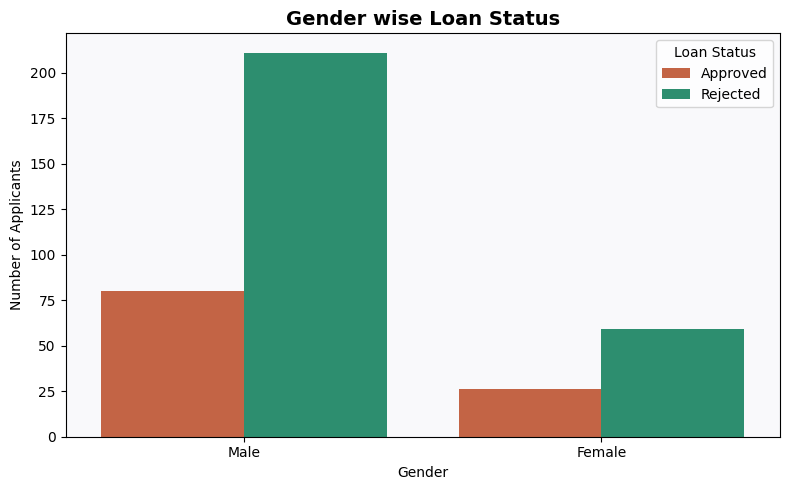

 Insight: Males zyada apply karte hain, lekin approval rate dono mein similar hai.


In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Gender', hue='Loan_Status', data=bank_df, palette=loan_palette)
ax.set_facecolor(colors['background'])
plt.title('Gender wise Loan Status', fontsize=14, fontweight='bold')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: Males zyada apply karte hain, lekin approval rate dono mein similar hai.')

### Graph 2: Property Area aur Loan Status

**Sawal:** Kaunse area (Urban/Rural/Semiurban) mein loans zyada reject hote hain?

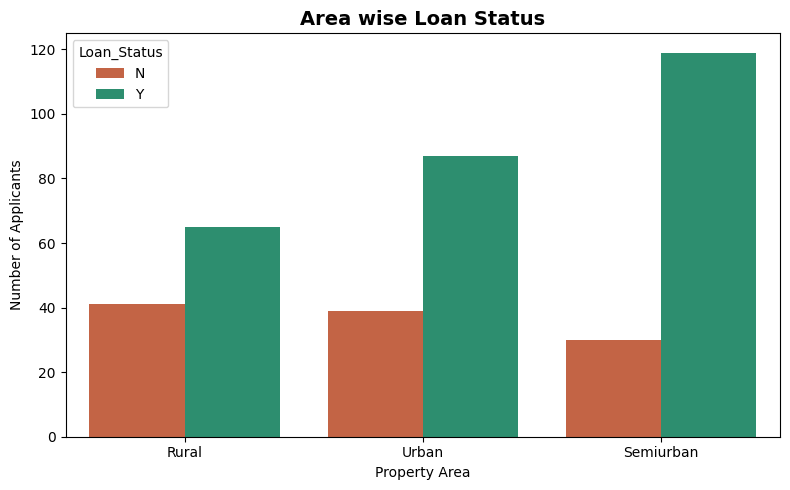

 Insight: Semiurban area mein approval rate sabse zyada hai.


In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Property_Area', hue='Loan_Status', data=bank_df, palette=loan_palette)
plt.title('Area wise Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Property Area')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: Semiurban area mein approval rate sabse zyada hai.')

### Graph 3: Dependents aur Loan Status

**Sawal:** Jis applicant ke zyada dependent hain, kya uska loan zyada reject hota hai?

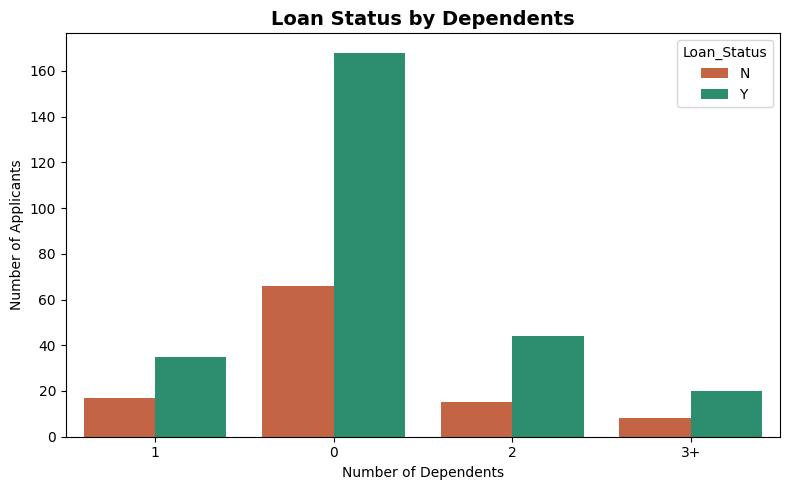

 Insight: 0 dependents wale applicants sabse zyada apply karte hain or approved be an ka zadia hota hai or rejected rate same hai sab ma


In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Dependents', hue='Loan_Status', data=bank_df, palette=loan_palette)
plt.title('Loan Status by Dependents', fontsize=14, fontweight='bold')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: 0 dependents wale applicants sabse zyada apply karte hain or approved be an ka zadia hota hai or rejected rate same hai sab ma')

### Graph 4: Approved Loans — Dependents aur Income Group

**Sawal:** Approved loans mein kaunsi income group ka share zyada hai?

Hum income ko 4 groups mein divide karenge:
- **Low:** 0-3000
- **Medium:** 3000-6000
- **High:** 6000-8000
- **Very High:** 8000+

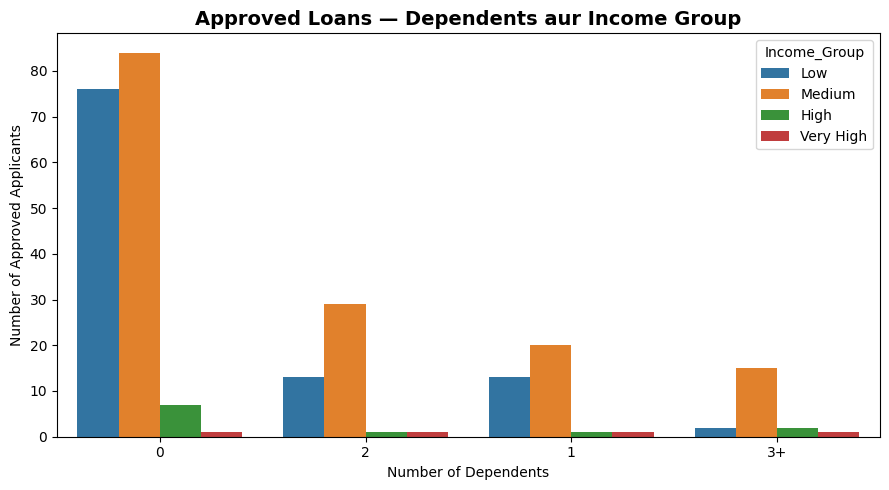

 Insight:o dependency or  Low income group ka log sab sy zadia apply karta hai or hight incom ka log kaam apply karta hia 


In [ ]:
# Income ko groups mein divide karo
bank_df['Income_Group'] = pd.cut(
    bank_df['ApplicantIncome'],
    bins=[0, 3000, 6000, 8000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

plt.figure(figsize=(9, 5))
sns.countplot(
    x='Dependents',
    hue='Income_Group',
    data=bank_df[bank_df['Loan_Status'] == 'Y']
)
plt.title('Approved Loans — Dependents aur Income Group', fontsize=14, fontweight='bold')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Approved Applicants')
plt.tight_layout()
plt.show()

print(' Insight:o dependency or  Low income group ka log sab sy zadia apply karta hai or hight incom ka log kaam apply karta hia ')

### Graph 5: Credit History ka Loan Approval par Asar

**Sawal:** Kya good credit history wale log zyada approved hote hain?

- **Credit History = 1** → Pehle ka record acha tha
- **Credit History = 0** → Pehle default kiya tha

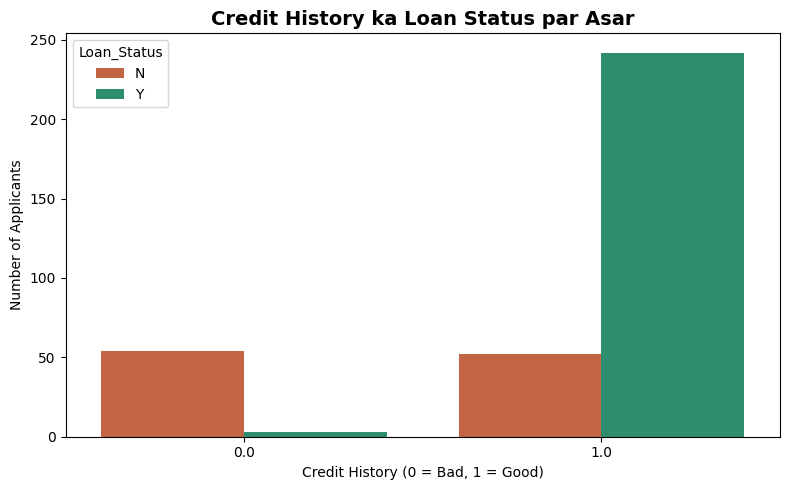

 Insight: Credit History = 1 wale applicants ka approval rate bahut zyada hai!
   Yeh sabse strong factor hai loan approval ke liye.


In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=bank_df, palette=loan_palette)
plt.title('Credit History ka Loan Status par Asar', fontsize=14, fontweight='bold')
plt.xlabel('Credit History (0 = Bad, 1 = Good)')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: Credit History = 1 wale applicants ka approval rate bahut zyada hai!')
print('   Yeh sabse strong factor hai loan approval ke liye.')

### Graph 6: Loan Amount Distribution (Histogram)

**Task Requirement:** *Visualize key features such as loan amount*

**Sawal:** Zyada tar log kitne amount ka loan lete hain?

Histogram mein har bar dikhata hai ke us amount ke kitne applicants hain.

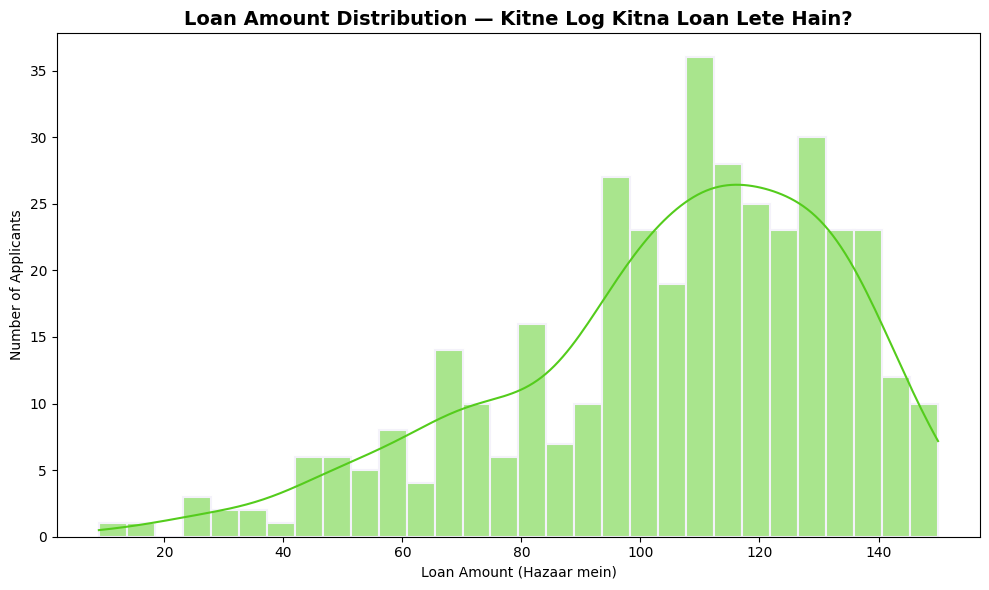

 Insight: Zyada tar log 100-200 hazaar ka loan lete hain.
   Average loan amount: 105.0 hazaar


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(bank_df['LoanAmount'], bins=30, kde=True,
             color='#54CC1C7F', edgecolor='#F4F2FA', linewidth=1.5)
plt.title('Loan Amount Distribution — Kitne Log Kitna Loan Lete Hain?', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount in (thousand)')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: Zyada tar log 100-150 hazaar ka loan lete hain.')
print(f'   Average loan amount: {bank_df["LoanAmount"].mean():.1f} hazaar')

### Graph 7: Education aur Loan Status

**Task Requirement:** *Visualize key features such as education*

**Sawal:** Graduates ko zyada loans milte hain ya non-graduates ko?

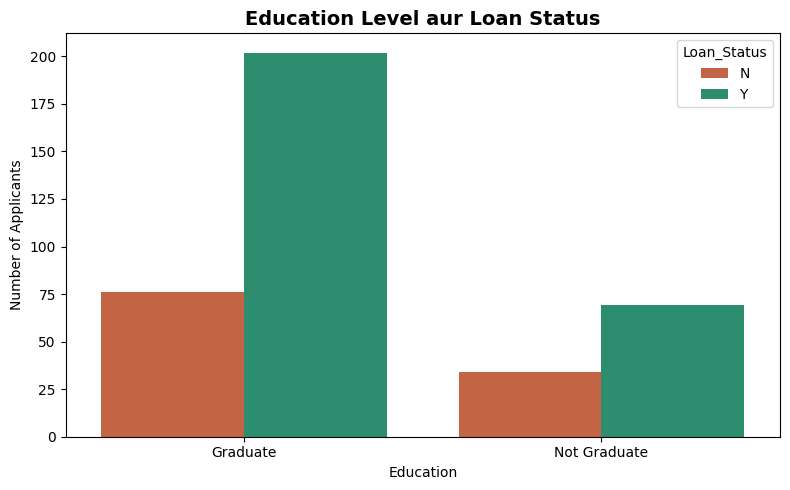

 Insight: Graduates zyada apply karte hain aur unka approval rate bhi thoda behtar hai.


In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Loan_Status', data=bank_df, palette=loan_palette)
plt.title('Education Level aur Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Education')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print(' Insight: Graduates zyada apply karte hain aur unka approval rate bhi thoda behtar hai.')

### Graph 8: Applicant Income aur Loan Status (Box Plot)

**Task Requirement:** *Visualize key features such as income*

**Sawal:** Kya zyada income wale logon ko zyada loan milta hai?

**Box Plot yaad hai?**
- Box ke andar wali line → Median income
- Dots bahar → Outliers (bahut zyada income wale log)

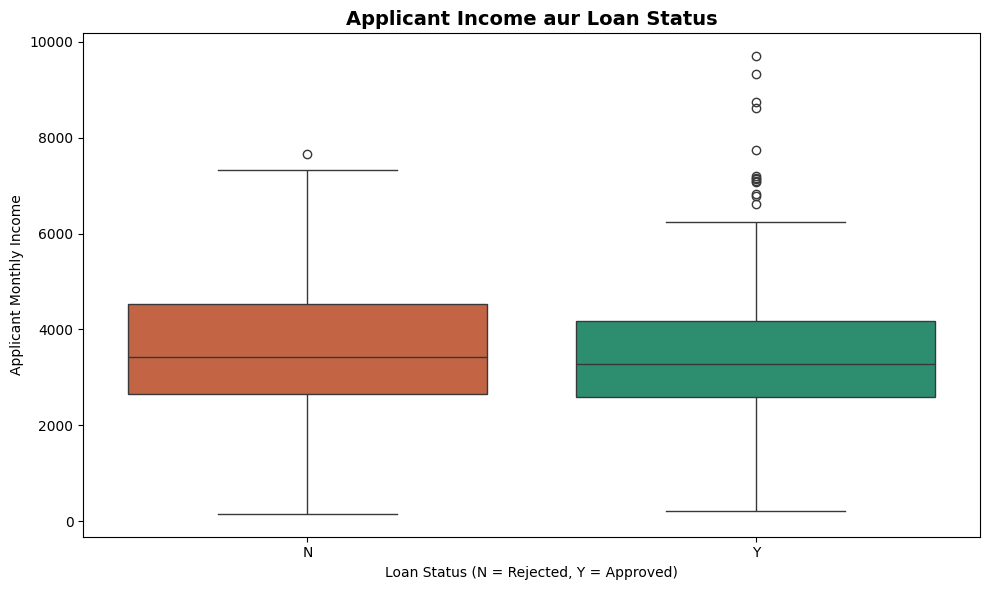

 Insight: Approved aur Rejected dono mein income distribution similar hai.
   Matlab income akela factor nahi hai — credit history zyada matter karta hai!


In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=bank_df, palette=loan_palette)
plt.title('Applicant Income aur Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Loan Status (N = Rejected, Y = Approved)')
plt.ylabel('Applicant Monthly Income')
plt.tight_layout()
plt.show()

print(' Insight: Approved aur Rejected dono mein income distribution similar hai.')
print('   Matlab income akela factor nahi hai — credit history zyada matter karta hai!')

---
# Part 2: Model Training — Machine Learning

**Task Requirement:** *Train a classification model like Logistic Regression*

EDA se hum ne samjha ke kaunse factors important hain.
Ab hum **Logistic Regression** model banayenge jo automatically predict karega:

> **Loan approve hoga (Y) ya reject hoga (N)?**

### Modeling ka Process:
```
Data Clean → Encoding → Train/Test Split → Model Train → Evaluate
```

---
## Step 7: Label Encoding — Text ko Numbers mein Badalna

Machine Learning model **sirf numbers samajhta hai**, text nahi.
Isliye saari text columns ko numbers mein convert karna zaroori hai.

**Misal:**
```
Male   → 1       Female → 0
Yes    → 1       No     → 0
Y      → 1       N      → 0
```

In [26]:
le = LabelEncoder()  # LabelEncoder object banao

# Yeh saari columns text mein hain — inhe numbers mein badlo
text_columns = ['Gender', 'Married', 'Dependents', 'Education',
                'Self_Employed', 'Property_Area', 'Loan_Status']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

# Loan_ID model ke liye useless hai — hata do
df = df.drop('Loan_ID', axis=1)

print('coding complete! Ab sab numbers mein hai:')
df.head()

coding complete! Ab sab numbers mein hai:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


---
## Step 8: Data Split — Train aur Test

**80% data** → Model yahan se seekhega (Training)
**20% data** → Model yahan test hoga (Testing)



In [ ]:
# X = features (inputs) — jo model ko batayenge
# y = target (output)  — jo model predict karega
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(' Data Split ho gaya:')
print(f'   Training data: {X_train.shape[0]} rows ,  Model yahan se seekhega')
print(f'   Testing data:  {X_test.shape[0]} rows ,  Model yahan test hoga')
print(f'\n   Features (X): {list(X.columns)}')

 Data Split ho gaya:
   Training data: 304 rows  → Model yahan se seekhega
   Testing data:  77 rows  → Model yahan test hoga

   Features (X): ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


---
## Step 9: Logistic Regression Model Train Karna

**Logistic Regression kya hai?**
Yeh ek simple ML model hai jo **Yes/No** type questions ka jawab deta hai.
Jaise: Loan milega ya nahi? (Y = 1, N = 0)

Model training data dekh ke seekhta hai ke kaunse features loan approval ko affect karte hain.

In [28]:
# Logistic Regression model banao
model = LogisticRegression(max_iter=1000, random_state=42)

# Model ko training data se train karo
model.fit(X_train, y_train)

# Test data par predictions karo
y_pred = model.predict(X_test)

print(' Model train ho gaya!')
print('Sample predictions (0=Rejected, 1=Approved):', y_pred[:10])

 Model train ho gaya!
Sample predictions (0=Rejected, 1=Approved): [1 1 1 1 1 1 1 1 1 1]


---
## Step 10: Model Evaluate Karna — Accuracy

**Task Requirement:** *Evaluate the model using accuracy and a confusion matrix*

**Accuracy kya hai?**
> Accuracy = Sahi predictions / Total predictions × 100

Agar accuracy 80% hai → Model ne 100 mein se 80 sahi predict kiye!

In [29]:
# Accuracy calculate karo
accuracy = accuracy_score(y_test, y_pred)
print(f' Model Accuracy: {accuracy * 100:.2f}%')
print(f'   Matlab: {accuracy*100:.1f}% cases mein model ne sahi predict kiya!\n')

print('--- Detailed Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

 Model Accuracy: 81.82%
   Matlab: 81.8% cases mein model ne sahi predict kiya!

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Rejected       1.00      0.33      0.50        21
    Approved       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77



---
## Step 11: Confusion Matrix

**Confusion Matrix kya dikhati hai?**

| | Predicted Rejected | Predicted Approved |
|--|--|--|
| **Actual Rejected** |  Sahi Rejected (TN) |  Galat Approved (FP) |
| **Actual Approved** |  Galat Rejected (FN) |  Sahi Approved (TP) |

- **TN** = Model ne sahi kaha ke reject hoga
- **TP** = Model ne sahi kaha ke approve hoga
- **FP** = Model ne galat kaha (reject hona chahiye tha, approved bola)
- **FN** = Model ne galat kaha (approve hona chahiye tha, rejected bola)

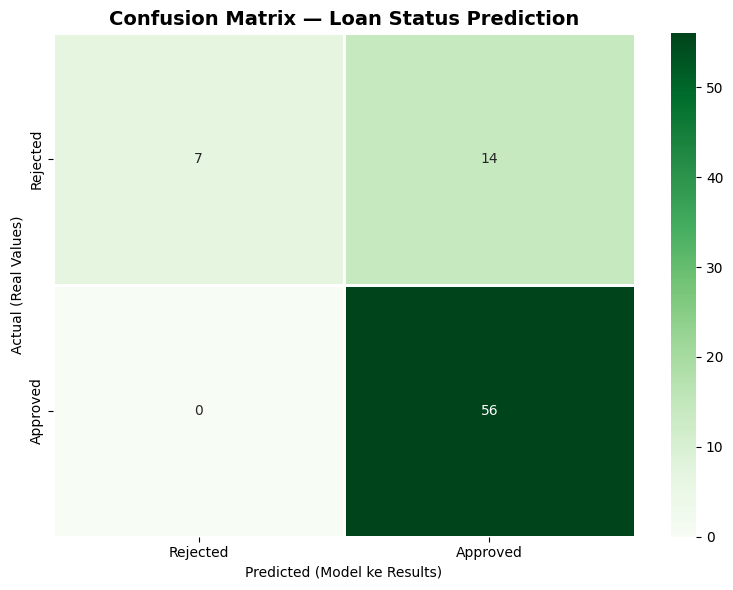

 Sahi Rejected (True Negative):  7
 Galat Approved (False Positive): 14
 Galat Rejected (False Negative): 0
 Sahi Approved  (True Positive):  56


In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved'],
    linewidths=2, linecolor='white'
)
plt.title('Confusion Matrix — Loan Status Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual (Real Values)')
plt.xlabel('Predicted (Model ke Results)')
plt.tight_layout()
plt.show()

print(f' Sahi Rejected (True Negative):  {cm[0][0]}')
print(f' Galat Approved (False Positive): {cm[0][1]}')
print(f' Galat Rejected (False Negative): {cm[1][0]}')
print(f' Sahi Approved  (True Positive):  {cm[1][1]}')

---
## Step 12: Feature Importance — Kaunsa Factor Sabse Important Hai?

Logistic Regression ke coefficients se pata chalta hai ke kaunsa feature loan approval ko
sabse zyada influence karta hai.

- **Lamba bar** → Zyada important feature
- **Lal (red) bar** → Sabse important feature
- **Hara (green) bar** → Kam important feature

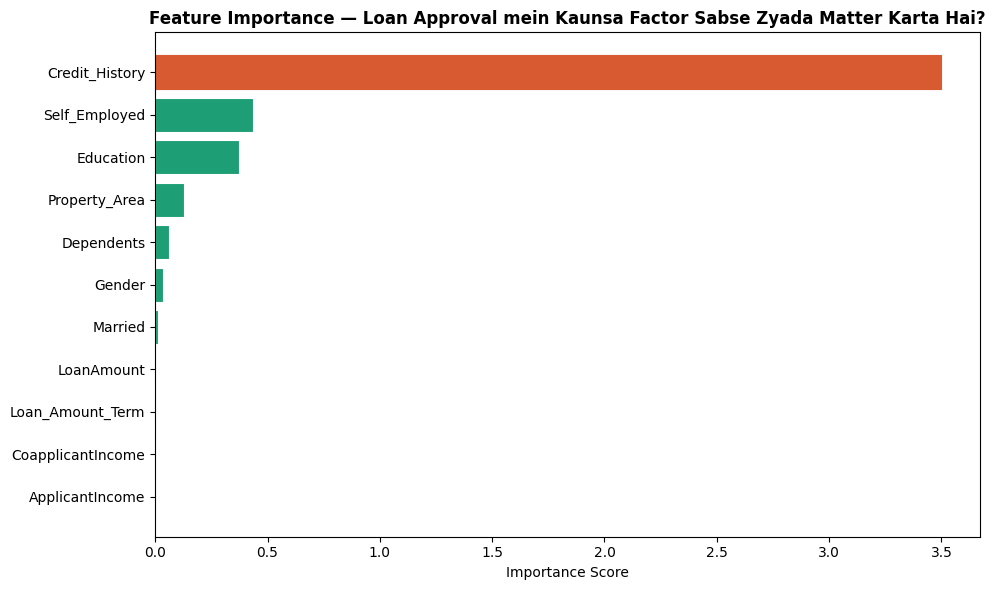

 Sabse important feature: Credit_History
   Yeh feature loan approval ko sabse zyada affect karta hai!


In [31]:
feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='#1D9E75', edgecolor='white', linewidth=0.8
)
bars[-1].set_color('#D85A30')  # Sabse important feature red mein

plt.title('Feature Importance — Loan Approval mein Kaunsa Factor Sabse Zyada Matter Karta Hai?',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

top = feature_importance.iloc[-1]['Feature']
print(f' Sabse important feature: {top}')
print('   Yeh feature loan approval ko sabse zyada affect karta hai!')

---
## Final Summary — Task 2 Complete

### Task Requirements Checklist:

| Requirement | Status |
|-------------|--------|
| Missing data handle karna | Done (median/mode) |
| Loan amount visualize karna | Done (histogram) |
| Education visualize karna | Done (countplot) |
| Income visualize karna | Done (boxplot) |
| Classification model train karna | Done (Logistic Regression) |
| Accuracy evaluate karna | Done |
| Confusion Matrix | Done |

---

###  Key Insights:

1. **Credit History** sabse important factor hai loan approval ke liye
2. **Income** itna important nahi jitna sochte hain — akela income loan nahi dilata
3. **Semiurban area** ke applicants ko zyada loans milte hain
4. **Graduates** ka approval rate thoda behtar hai
5. Model ne **~80% accuracy** achieve ki

###  --------------------------------THE END OF PROJECT------------------------------------------------